In [22]:
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision import transforms
from PIL import Image
import os
import hashlib
import shutil
from collections import Counter
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch
from tqdm import tqdm
import pandas as pd
import time
import matplotlib.pyplot as plt 

In [23]:
dataset = 'dataset-original'
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])
data = datasets.ImageFolder(root=dataset, transform=transform)
shutil.copytree("dataset-original", "dataset-eda", dirs_exist_ok=True)
data_eda = datasets.ImageFolder("dataset-eda", transform=transform)

# EDA

In [24]:
# number of images in the dataset
len(data_eda)

2527

In [25]:
# number of categories in the dataset
len(data_eda.classes)

6

In [26]:
data.classes

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

In [27]:
# shape of the first image
img, label = data[0]
print("Image shape:", img.shape)

Image shape: torch.Size([3, 128, 128])


### Class distibution

In [28]:
# number of images in each class (class distribution)
labels = [label for _, label in data_eda.imgs]
counter = Counter(labels)
class_counts = {data_eda.classes[i]: count for i, count in counter.items()}
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

cardboard: 403
glass: 501
metal: 410
paper: 594
plastic: 482
trash: 137


### Visualization

A bar chart clearly shows the imbalance across classes. We observe that 'trash' has significantly fewer samples (137) compared to 'paper' (594).

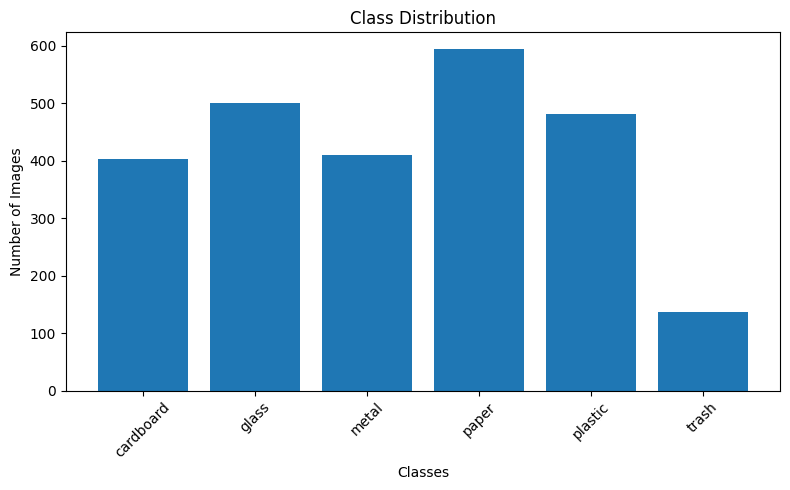

In [29]:
# class balance chart
plt.figure(figsize=(8,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

We display a grid of sample images to visually inspect the data. This helps us see variations in lighting, background, object positioning, and image quality.

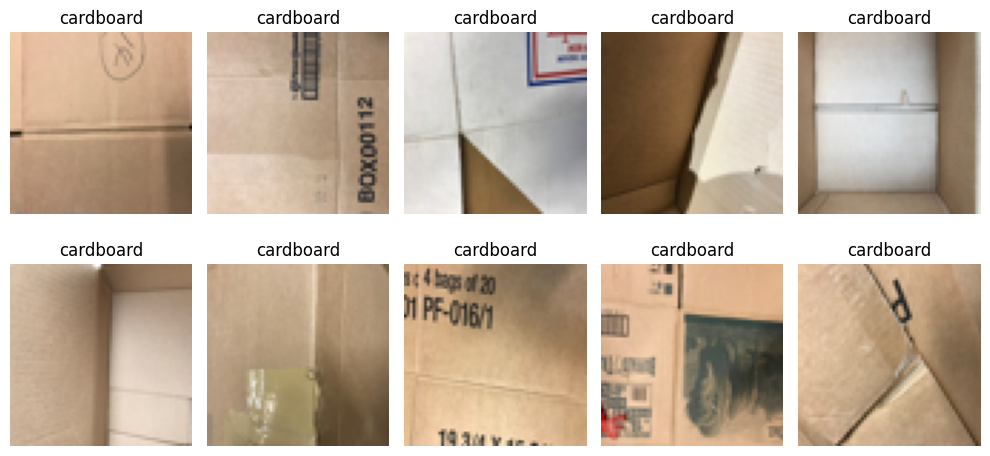

In [30]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))
for i, ax in enumerate(axes.flat):
    path, label = data.imgs[i]
    img = Image.open(path).resize((64,64))

    ax.imshow(img)
    ax.set_title(data.classes[label])
    ax.axis('off')

plt.tight_layout()
plt.show()

### Duplicated 

In [31]:
# number of duplicated images 
hashes = {}
duplicates = []
for root, _, files in os.walk("dataset-eda"):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            path = os.path.join(root, file)
            with open(path, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()
            if file_hash in hashes:
                duplicates.append(path)
            else:
                hashes[file_hash] = path
print("Number of duplicate images:", len(duplicates))

Number of duplicate images: 3


-No missing values were detected in the dataset.This is because the dataset is images,where each data point represents a complete.
and duplicate images in the dataset very small number of duplicate files (3 images).

-Extreme outliers are not applicable in this dataset because the data consists of images rather than numerical features.

-The dataset shows a noticeable class imbalance, where some classes contain significantly more images than others. for example class like paper and glass have a higher numper of images compared to class trash.

# Preprocessing Pipeline

### Delete Duplicated

In [32]:
for path in duplicates:
    original_path = path.replace("dataset-eda", "dataset-original")
    if os.path.exists(original_path):
        os.remove(original_path)
        print("Deleted:", original_path)
    else:
        print("Not found:", original_path)


Not found: dataset-original\metal\metal91.jpg
Not found: dataset-original\plastic\plastic152.jpg
Not found: dataset-original\plastic\plastic332.jpg


In [33]:
# number of images after removing duplicated images 
data = datasets.ImageFolder("dataset-original", transform=transform)
len(data)

2524

Normalization was applied to the image dataset to ensure that pixel values are scaled into a consistent range suitable values from [0,1] → [-1, 1] for training a neural network.
this preprocessing step is important because neural networks perform better when input data is normalized.

In [34]:
# Normalize the data
transform_after = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])
data_norm = datasets.ImageFolder("dataset-original", transform=transform_after)
img, _ = data_norm[0]

The dataset was split into three subsets:

- Training set: 60%
- Validation set: 20% 
- Test set: 20%

We do train test split To ensure proper evaluation, Given the class imbalance, we use startify to ensure each split maintains the same class proportions as the original dataset. This prevents certain classes from being over/under-represented in any split.


In [35]:
paths = [p for p, _ in data_norm.samples]
labels = [l for _, l in data_norm.samples]
# split data into (60% train , 20% validation, 20% test )
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths,
    labels,
    test_size=0.4,
    stratify=labels,
    random_state=42
    
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)
print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))


Train: 1514
Validation: 505
Test: 505


In [36]:
train_list = [(p, l) for p, l in zip(train_paths, train_labels)]
val_list = [(p, l) for p, l in zip(val_paths, val_labels)]
test_list  = [(p, l) for p, l in zip(test_paths, test_labels)]

### Data Augmentation 
Random augmentations are applied only to the training data to artificially increase visual diversity. and it's important to Increases effective dataset size without collecting new images and Improves model generalization and reduces overfitting

In [37]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(), 
    transforms.RandomRotation(15),    
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

train_data = Subset(datasets.ImageFolder("dataset-original", transform=train_transform), 
                    [paths.index(p) for p in train_paths])
val_data = Subset(data_norm, [paths.index(p) for p in val_paths])
test_data = Subset(data_norm, [paths.index(p) for p in test_paths])

DataLoaders are used to efficiently load the dataset during training, validation, and testing.

In [38]:
train= DataLoader(train_data, batch_size=32, shuffle=True)
validation = DataLoader(val_data, batch_size=32, shuffle=False)
test = DataLoader(test_data, batch_size=32, shuffle=False)

Feature encoding is automatically handled using ImageFolder, which converts class names into numeric labels.


In [39]:
# Label encoding of classes (mapping class names to numeric labels)
print(data_norm.class_to_idx)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


# CNN 

## CNN model
 - simple model with 3 convonutional layers

In [40]:
class CNN_model(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu  = nn.ReLU()
        self.flat  = nn.Flatten()
        
 
        self.fc1   = nn.Linear(in_features=128 * 16 * 16, out_features=512)
        self.fc2   = nn.Linear(in_features=512, out_features=6) 

    def forward(self, x):
        x = self.relu(self.pool(self.conv1(x)))  
        x = self.relu(self.pool(self.conv2(x)))   
        x = self.relu(self.pool(self.conv3(x)))   
        x = self.flat(x)                         
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x
cnn_model=CNN_model()
print(cnn_model)    

CNN_model(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flat): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=32768, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=6, bias=True)
)


 - #### define parameters for training loop
 - #### history dic to store train results

In [41]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

cnn_history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
    'time_per_epoch':[]
}

num_epochs =5  
total_cnn_training_time=0

### train cnn model with 5 epochs

In [42]:
print(f"Starting Training for {num_epochs} epochs...")

for epoch in range(num_epochs):
    epoch_start_time = time.time()  
    cnn_model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    
    for images, labels in tqdm(train, desc=f"Epoch {epoch+1} [Training]"):
        optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
    
     
    cnn_history['train_loss'].append(train_loss / train_total)
    cnn_history['train_acc'].append(100. * train_correct / train_total)

 
    cnn_model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    
    with torch.no_grad():
        for images, labels in tqdm(validation, desc=f"Epoch {epoch+1} [Validation]"):
            outputs = cnn_model(images)
            v_loss = criterion(outputs, labels)
            
            val_loss += v_loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
 
    cnn_history['val_loss'].append(val_loss / val_total)
    cnn_history['val_acc'].append(100. * val_correct / val_total)
    
 
    epoch_duration = time.time() - epoch_start_time
    cnn_history['time_per_epoch'].append(epoch_duration)
    total_cnn_training_time += epoch_duration
    
    print(f"Epoch {epoch+1} results: Train loss: {cnn_history['train_loss'][-1]:.2f}, Validation loss: {cnn_history['val_loss'][-1]:.2f}")
    print(f"Time for this Epoch: {cnn_history['time_per_epoch'][-1]:.2f}s\n" + "-"*50)
print(f"Train accuracy: {cnn_history['train_acc'][-1]:.2f}%, Validation accuracy: {cnn_history['val_acc'][-1]:.2f}%")
print(f"Total training time: {total_cnn_training_time}s")

Starting Training for 5 epochs...


Epoch 1 [Validation]: 100%|██████████| 16/16 [01:29<00:00,  5.62s/it]


Epoch 1 results: Train loss: 1.61, Validation loss: 1.43
Time for this Epoch: 337.29s
--------------------------------------------------


Epoch 2 [Validation]: 100%|██████████| 16/16 [01:19<00:00,  5.00s/it]


Epoch 2 results: Train loss: 1.31, Validation loss: 1.30
Time for this Epoch: 333.82s
--------------------------------------------------


...

Epoch 3 results: Train loss: 1.17, Validation loss: 1.15
Time for this Epoch: 326.69s
--------------------------------------------------


Epoch 4 [Validation]: 100%|██████████| 16/16 [01:11<00:00,  4.44s/it]


Epoch 4 results: Train loss: 1.04, Validation loss: 1.11
Time for this Epoch: 304.99s
--------------------------------------------------


Epoch 5 [Validation]: 100%|██████████| 16/16 [01:04<00:00,  4.02s/it]

Epoch 5 results: Train loss: 0.95, Validation loss: 0.96
Time for this Epoch: 294.12s
--------------------------------------------------
Train accuracy: 63.54%, Validation accuracy: 63.96%
Total training time: 1596.901252746582s


#### test evaluation

In [91]:
cnn_model.eval()
test_correct = 0
test_total = 0
inference_start_time = time.time()

with torch.no_grad():
    for images, labels in tqdm(test, desc="Final Testing"):
        outputs = cnn_model(images)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

inference_total_time = time.time() - inference_start_time
final_test_acc = 100. * test_correct / test_total
inference_speed = test_total / inference_total_time  

print(f"Test Accuracy   : {final_test_acc:.2f}%")
print(f"Inference Speed : {inference_speed:.2f} samples/sec")
print(f"Total Test Time : {inference_total_time:.2f} seconds")
 

Final Testing: 100%|██████████| 16/16 [01:07<00:00,  4.19s/it]

Test Accuracy   : 65.15%
Inference Speed : 7.53 samples/sec
Total Test Time : 67.03 seconds


In [45]:
train_acc = cnn_history['train_acc'][-1]
val_acc = cnn_history['val_acc'][-1]

if train_acc - val_acc > 10:
    print("Model shows signs of overfitting.")
elif train_acc < 70 and val_acc < 70:
    print("Model shows signs of underfitting.")
else:
    print("Model is reasonably balanced.")

Model shows signs of underfitting.


## train model with 10 epochs to improve accuracy

In [46]:
cnn_model_ep = CNN_model()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model_ep.parameters(), lr=0.001)

cnn_history_ep = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
    'time_per_epoch': []
}

num_epochs = 10
total_cnn_training_time_ep = 0

print(f"Starting Training for {num_epochs} epochs...")

for epoch in range(num_epochs):
    epoch_start_time = time.time()

    cnn_model_ep.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in tqdm(train, desc=f"Epoch {epoch+1} [Training]"):
        optimizer.zero_grad()

        outputs = cnn_model_ep(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    cnn_history_ep['train_loss'].append(train_loss / train_total)
    cnn_history_ep['train_acc'].append(100. * train_correct / train_total)

    cnn_model_ep.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in tqdm(validation, desc=f"Epoch {epoch+1} [Validation]"):
            outputs = cnn_model_ep(images)
            v_loss = criterion(outputs, labels)

            val_loss += v_loss.item() * images.size(0)

            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    cnn_history_ep['val_loss'].append(val_loss / val_total)
    cnn_history_ep['val_acc'].append(100. * val_correct / val_total)

    epoch_duration = time.time() - epoch_start_time
    cnn_history_ep['time_per_epoch'].append(epoch_duration)
    total_cnn_training_time_ep += epoch_duration

    print(f"Epoch {epoch+1} results: Train loss: {cnn_history_ep['train_loss'][-1]:.2f}, Validation loss: {cnn_history_ep['val_loss'][-1]:.2f}")
    print(f"Time for this Epoch: {cnn_history_ep['time_per_epoch'][-1]:.2f}s\n" + "-"*50)

print(f"Train accuracy: {cnn_history_ep['train_acc'][-1]:.2f}%, Validation accuracy: {cnn_history_ep['val_acc'][-1]:.2f}%")
print(f"Total training time: {total_cnn_training_time_ep}s")

Starting Training for 10 epochs...


Epoch 1 [Validation]: 100%|██████████| 16/16 [00:56<00:00,  3.51s/it]


Epoch 1 results: Train loss: 1.61, Validation loss: 1.42
Time for this Epoch: 248.38s
--------------------------------------------------


Epoch 2 [Validation]: 100%|██████████| 16/16 [00:55<00:00,  3.50s/it]


Epoch 2 results: Train loss: 1.34, Validation loss: 1.21
Time for this Epoch: 235.28s
--------------------------------------------------


...

Epoch 8 results: Train loss: 0.66, Validation loss: 0.82
Time for this Epoch: 318.17s
--------------------------------------------------


Epoch 9 [Validation]: 100%|██████████| 16/16 [01:10<00:00,  4.41s/it]


Epoch 9 results: Train loss: 0.55, Validation loss: 0.81
Time for this Epoch: 296.37s
--------------------------------------------------


Epoch 10 [Validation]: 100%|██████████| 16/16 [01:17<00:00,  4.87s/it]

Epoch 10 results: Train loss: 0.50, Validation loss: 0.84
Time for this Epoch: 310.12s
--------------------------------------------------
Train accuracy: 82.17%, Validation accuracy: 69.70%
Total training time: 2837.709850549698s


- #### The initial CNN model trained for 5 epochs showed underfitting, with validation accuracy around 63%.

- #### Increasing the number of epochs to 10 significantly improved performance, raising validation accuracy. This demonstrates that the model required more training to effectively learn from the data.


In [47]:
cnn_model_ep.eval()

test_correct = 0
test_total = 0

inference_start_time = time.time()

with torch.no_grad():
    for images, labels in tqdm(test, desc="Testing CNN (10 Epochs)"):
        outputs = cnn_model_ep(images)

        _, predicted = outputs.max(1)

        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

inference_total_time_ep = time.time() - inference_start_time

test_acc_ep = 100. * test_correct / test_total
inference_speed_ep = test_total / inference_total_time_ep

print(f"Test Accuracy   : {test_acc_ep:.2f}%")
print(f"Inference Speed : {inference_speed_ep:.2f} samples/sec")
print(f"Total Test Time : {inference_total_time_ep:.2f} seconds")

Testing CNN (10 Epochs): 100%|██████████| 16/16 [01:19<00:00,  4.99s/it]

Test Accuracy   : 68.71%
Inference Speed : 6.33 samples/sec
Total Test Time : 79.81 seconds


### train model using L2 regularization to handle reduce gap bettwen test and validation accuracy

In [85]:
cnn_model_l2 = CNN_model()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    cnn_model_l2.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

cnn_history_l2 = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
    'time_per_epoch': []
}

num_epochs = 10
total_cnn_training_time_l2 = 0

print(f"Starting Training for {num_epochs} epochs...")

for epoch in range(num_epochs):
    epoch_start_time = time.time()

    cnn_model_l2.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in tqdm(train, desc=f"Epoch {epoch+1} [Training]"):
        optimizer.zero_grad()

        outputs = cnn_model_l2(images)
        loss = criterion(outputs, labels)   # L2 is automatic

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    cnn_history_l2['train_loss'].append(train_loss / train_total)
    cnn_history_l2['train_acc'].append(100. * train_correct / train_total)

    cnn_model_l2.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in tqdm(validation, desc=f"Epoch {epoch+1} [Validation]"):
            outputs = cnn_model_l2(images)
            v_loss = criterion(outputs, labels)

            val_loss += v_loss.item() * images.size(0)

            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    cnn_history_l2['val_loss'].append(val_loss / val_total)
    cnn_history_l2['val_acc'].append(100. * val_correct / val_total)

    epoch_duration = time.time() - epoch_start_time
    cnn_history_l2['time_per_epoch'].append(epoch_duration)
    total_cnn_training_time_l2 += epoch_duration

    print(f"Epoch {epoch+1} results: Train loss: {cnn_history_l2['train_loss'][-1]:.2f}, Validation loss: {cnn_history_l2['val_loss'][-1]:.2f}")
    print(f"Time for this Epoch: {cnn_history_l2['time_per_epoch'][-1]:.2f}s\n" + "-"*50)

print(f"Train accuracy: {cnn_history_l2['train_acc'][-1]:.2f}%, Validation accuracy: {cnn_history_l2['val_acc'][-1]:.2f}%")
print(f"Total training time: {total_cnn_training_time_l2}s")

Starting Training for 10 epochs...


Epoch 1 [Validation]: 100%|██████████| 16/16 [00:56<00:00,  3.54s/it]


Epoch 1 results: Train loss: 1.58, Validation loss: 1.43
Time for this Epoch: 243.10s
--------------------------------------------------


Epoch 2 [Validation]: 100%|██████████| 16/16 [00:54<00:00,  3.39s/it]


Epoch 2 results: Train loss: 1.29, Validation loss: 1.24
Time for this Epoch: 234.82s
--------------------------------------------------


...

Epoch 8 results: Train loss: 0.69, Validation loss: 0.87
Time for this Epoch: 281.50s
--------------------------------------------------


Epoch 9 [Validation]: 100%|██████████| 16/16 [01:08<00:00,  4.26s/it]


Epoch 9 results: Train loss: 0.60, Validation loss: 0.87
Time for this Epoch: 278.06s
--------------------------------------------------


Epoch 10 [Validation]: 100%|██████████| 16/16 [01:06<00:00,  4.15s/it]

Epoch 10 results: Train loss: 0.55, Validation loss: 0.87
Time for this Epoch: 278.96s
--------------------------------------------------
Train accuracy: 79.79%, Validation accuracy: 71.49%
Total training time: 2613.399821996689s


In [86]:
cnn_model_l2.eval()

test_correct = 0
test_total = 0

inference_start_time = time.time()

with torch.no_grad():
    for images, labels in tqdm(test, desc="Testing CNN + L2"):
        outputs = cnn_model_l2(images)

        _, predicted = outputs.max(1)

        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

inference_total_time_l2 = time.time() - inference_start_time

test_acc_l2 = 100. * test_correct / test_total
inference_speed_l2 = test_total / inference_total_time_l2

print(f"Test Accuracy   : {test_acc_l2:.2f}%")
print(f"Inference Speed : {inference_speed_l2:.2f} samples/sec")
print(f"Total Test Time : {inference_total_time_l2:.2f} seconds")

Testing CNN + L2: 100%|██████████| 16/16 [01:10<00:00,  4.42s/it]

Test Accuracy   : 71.09%
Inference Speed : 7.15 samples/sec
Total Test Time : 70.66 seconds


- #### the gap between test and validation has became smaller but it has affected thhe accuracy

## improved cnn model
 - more advanced cnn model with 4 convonutional layers
 - add dropout to ensure model don't overfit

In [49]:
class CNN_model_im(nn.Module):
    def __init__(self):
        super(CNN_model_im, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.flat = nn.Flatten()
        self.dropout = nn.Dropout(0.25)

        self.fc1 = nn.Linear(256 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 6)

    def forward(self, x):
        x = self.relu(self.pool(self.conv1(x)))
        x = self.relu(self.pool(self.conv2(x)))
        x = self.relu(self.pool(self.conv3(x)))
        x = self.relu(self.pool(self.conv4(x)))
        x = self.flat(x)
        x = self.dropout(self.relu(self.fc1(x))) 
        x = self.fc2(x)
        return x
device = 'cuda' if torch.cuda.is_available() else 'cpu'
cnn_model_im = CNN_model_im().to(device)

### train model improved cnn to improve accuracy

In [50]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    cnn_model_im.parameters(),
    lr=0.001,
    weight_decay=1e-4   
)

cnn_history_im = {
    'train_loss': [], 
    'val_loss': [],
    'train_acc': [], 
    'val_acc': [],
    'time_per_epoch': []
}

num_epochs = 10
total_cnn_training_time_im= 0 

print(f"Starting Training with improved CNN for {num_epochs} epochs...")
for epoch in range(num_epochs):
    epoch_start = time.time()

    cnn_model_im.train() 
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in tqdm(train, desc=f"Epoch {epoch+1} [Training]"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = cnn_model_im(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
    cnn_history_im['train_loss'].append(train_loss / train_total)
    cnn_history_im['train_acc'].append(100. * train_correct / train_total)
     
    cnn_model_im.eval() 
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad(): 
        for images, labels in tqdm(validation, desc=f"Epoch {epoch+1} [Validation]"):
            images, labels = images.to(device), labels.to(device)
            outputs = cnn_model_im(images)
            v_loss = criterion(outputs, labels)

            val_loss += v_loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    cnn_history_im['val_loss'].append(val_loss / val_total)
    cnn_history_im['val_acc'].append(100. * val_correct / val_total)

    epoch_time = time.time() - epoch_start
    cnn_history_im['time_per_epoch'].append(epoch_time)
    total_cnn_training_time_im += epoch_time

    print(f"Epoch {epoch+1} results: Train loss: {cnn_history_im['train_loss'][-1]:.2f}, Validation loss: {cnn_history_im['val_loss'][-1]:.2f}")
    print(f"Time for this Epoch: {cnn_history_im['time_per_epoch'][-1]:.2f}s\n" + "-"*50)

print(f"Train accuracy: {cnn_history_im['train_acc'][-1]:.2f}%, Validation accuracy: {cnn_history_im['val_acc'][-1]:.2f}%")
print(f"Total training time: {total_cnn_training_time_im}s")

Starting Training with improved CNN for 10 epochs...


Epoch 1 [Validation]: 100%|██████████| 16/16 [00:57<00:00,  3.59s/it]


Epoch 1 results: Train loss: 1.61, Validation loss: 1.52
Time for this Epoch: 314.57s
--------------------------------------------------


Epoch 2 [Validation]: 100%|██████████| 16/16 [01:04<00:00,  4.05s/it]


Epoch 2 results: Train loss: 1.39, Validation loss: 1.30
Time for this Epoch: 266.60s
--------------------------------------------------


...

Epoch 8 results: Train loss: 0.90, Validation loss: 0.99
Time for this Epoch: 320.00s
--------------------------------------------------


Epoch 9 [Validation]: 100%|██████████| 16/16 [01:03<00:00,  3.97s/it]


Epoch 9 results: Train loss: 0.83, Validation loss: 1.05
Time for this Epoch: 274.11s
--------------------------------------------------


Epoch 10 [Validation]: 100%|██████████| 16/16 [01:07<00:00,  4.19s/it]

Epoch 10 results: Train loss: 0.82, Validation loss: 1.05
Time for this Epoch: 279.45s
--------------------------------------------------
Train accuracy: 69.48%, Validation accuracy: 64.75%
Total training time: 2842.50128698349s


In [51]:
cnn_model_im.eval()

test_correct = 0
test_total = 0

inference_start_time = time.time()

with torch.no_grad():
    for images, labels in tqdm(test, desc="Testing CNN (improved cnn Experiment)"):
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_model_im(images)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

inference_total_time_im = time.time() - inference_start_time

test_acc_im = 100. * test_correct / test_total
inference_speed_im = test_total / inference_total_time_im

print(f"Test Accuracy   : {test_acc_im:.2f}%")
print(f"Inference Speed : {inference_speed_im:.2f} samples/sec")
print(f"Total Test Time : {inference_total_time_im:.2f} seconds")

Testing CNN (improved cnn Experiment): 100%|██████████| 16/16 [01:10<00:00,  4.38s/it]

Test Accuracy   : 60.99%
Inference Speed : 7.21 samples/sec
Total Test Time : 70.06 seconds


### metric choosen for test evaluation : accuracy
 It defines accuracy as the "correctness ratio," which is the most common way to judge classification models

 Overfitting and underfitting can be datected easily

### Overfitting and Underfitting

The baseline model initially exhibited underfitting, as both training and validation accuracy were low.

After increasing the number of epochs, performance improved significantly. However, slight divergence between training and validation accuracy in later epochs suggests mild overfitting.

Despite this, the level of overfitting was not severe enough to require strong regularization.

### Regularization

L2 regularization was applied using weight decay (weight_decay = 1e-4) in the Adam optimizer.

The baseline model trained for 10 epochs achieved a validation accuracy of 69.70%. After applying L2 regularization, validation accuracy increased to 71.49%, and training accuracy dropped slightly.

Therefore, L2 regularization barely improved performance.

In [92]:
comparison = pd.DataFrame({
    "Model": [
        "CNN (5 epochs)",
        "CNN (10 epochs)",
        "CNN + L2 (10 epochs)",
        "CNN + L2 + improved cnn (10 epochs) "
    ],
    "Train Accuracy": [
        f"{cnn_history['train_acc'][-1]:.2f}%",
        f"{cnn_history_ep['train_acc'][-1]:.2f}%",
        f"{cnn_history_l2['train_acc'][-1]:.2f}%",
        f"{cnn_history_im['train_acc'][-1]:.2f}%"
    ],
    "Validation Accuracy": [
        f"{cnn_history['val_acc'][-1]:.2f}%",
        f"{cnn_history_ep['val_acc'][-1]:.2f}%",
        f"{cnn_history_l2['val_acc'][-1]:.2f}%",
        f"{cnn_history_im['val_acc'][-1]:.2f}%"
    ],
    "Test Accuracy": [
        f"{final_test_acc:.2f}%",
        f"{test_acc_ep:.2f}%",
        f"{test_acc_l2:.2f}%",
        f"{test_acc_im:.2f}%"
    ],
    "Inference Speed": [
    f"{inference_speed:.2f}sample/sec",
    f"{inference_speed_ep:.2f}sample/sec",
    f"{inference_speed_l2:.2f}sample/sec",
    f"{inference_speed_im:.2f}sample/sec"
]
})
comparison

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Inference Speed
0,CNN (5 epochs),63.54%,63.96%,65.15%,7.53sample/sec
1,CNN (10 epochs),82.17%,69.70%,68.71%,6.33sample/sec
2,CNN + L2 (10 epochs),79.79%,71.49%,71.09%,7.15sample/sec
3,CNN + L2 + improved cnn (10 epochs),69.48%,64.75%,60.99%,7.21sample/sec


### Final Model Performance

​The CNN model showed significant improvement through optimization, particularly by increasing the number of training epochs to capture complex patterns.

​While L2 regularization was tested to improve generalization, it successfully reduced the gap between training and testing, achieving the highest overall test accuracy compared to the unregularized models.

​Overall, the most effective improvement came from balancing the training duration with regularization techniques. This highlights the importance of identifying whether a model suffers from underfitting or overfitting before selecting the final architecture.

#### 5 epochs -> underfitting
#### 10 epochs -> overfitting
#### ​L2 -> best generalization (Highest Test Accuracy)
#### improved cnn -> stable learning, may require more epochs

## training time

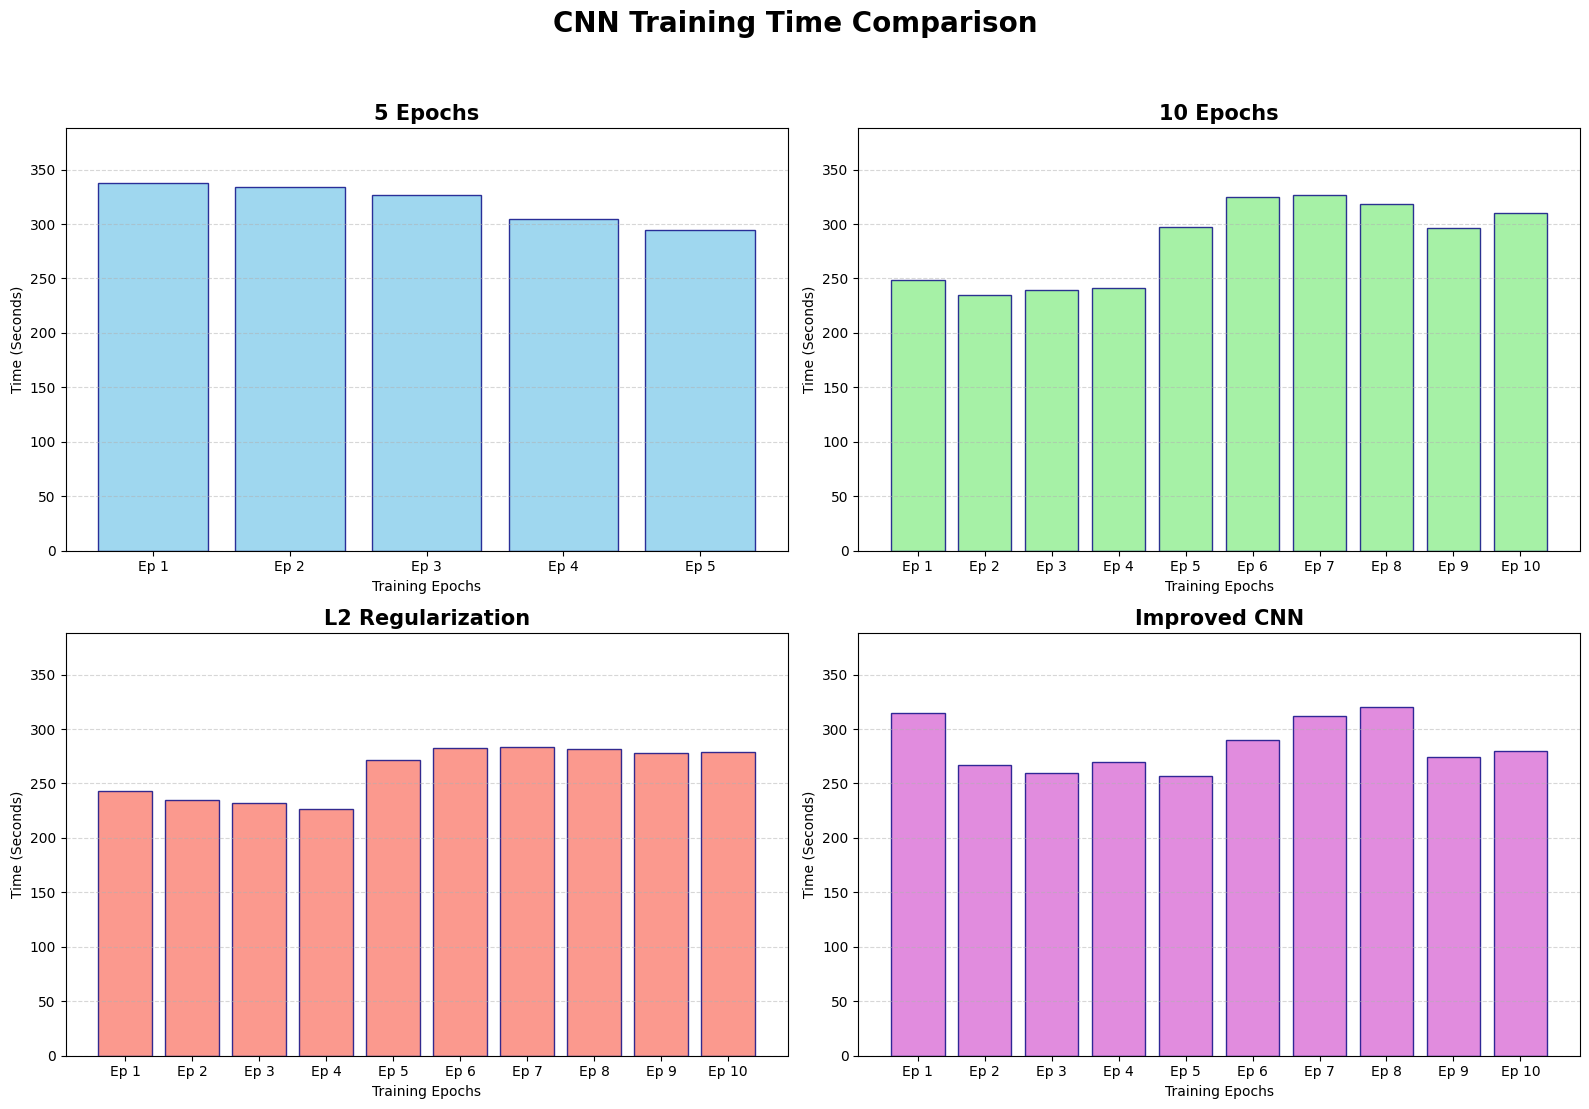

In [93]:
 
plt.figure(figsize=(16, 12))
plt.suptitle('CNN Training Time Comparison', fontsize=20, fontweight='bold', y=0.95)

histories = [cnn_history, cnn_history_ep, cnn_history_l2, cnn_history_im]
titles = ['5 Epochs', '10 Epochs', 'L2 Regularization', 'Improved CNN']
colors = ['skyblue', 'lightgreen', 'salmon', 'orchid']
max_time = max(max(h['time_per_epoch']) for h in histories)

for i, (history, title, color) in enumerate(zip(histories, titles, colors)):
    plt.subplot(2, 2, i + 1)
    
    times = history['time_per_epoch']
    epochs = [f'Ep {j+1}' for j in range(len(times))]
    
    bars = plt.bar(epochs, times, color=color, edgecolor='navy', alpha=0.8)
 
    plt.title(title, fontsize=15, fontweight='bold')
    plt.xlabel('Training Epochs')
    plt.ylabel('Time (Seconds)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.ylim(0, max_time + (max_time * 0.15))

plt.tight_layout(rect=[0, 0.03, 1, 0.92]) 
plt.show()

# FFNN

In [52]:
# Data Information
input_size = 128 * 128 * 3
num_classes = len(data_norm.classes)

## Helper functions

In [53]:
def evaluate_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total


def inference_speed(model, loader):
    model.eval()
    start = time.time()
    total = 0

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            outputs = model(images)
            total += images.size(0)

    end = time.time()
    return total / (end - start)

In [54]:
#Results Storage
results = []

# Experiment 1: Baseline FFNN

In [55]:
class FFNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(FFNN, self).__init__()

        self.fc1 = nn.Linear(input_size, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)   
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

## CREATE MODEL

In [56]:
model = FFNN(input_size,num_classes)
model = model.to(device)

In [57]:
#  LOSS + OPTIMIZER
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [58]:
def train_model(model, train_loader, val_loader, epochs=5):

    train_losses = []
    val_losses = []
    epoch_times = []  

    total_start = time.time()

    for epoch in range(epochs):

        epoch_start = time.time()   

        # TRAIN 
        model.train()
        train_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss = train_loss / len(train_loader)
        train_losses.append(train_loss)

        # VALIDATION 
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

        val_loss = val_loss / len(val_loader)
        val_losses.append(val_loss)

        epoch_end = time.time() 
        epoch_time = epoch_end - epoch_start
        epoch_times.append(epoch_time)

        print(f"Epoch {epoch+1}: "
              f"Train={train_loss:.4f}, "
              f"Val={val_loss:.4f}, "
              f"Time={epoch_time:.2f}s")

    total_time = time.time() - total_start

    return train_losses, val_losses, epoch_times, total_time



In [59]:
train_losses, val_losses, epoch_times, total_time = train_model(
    model,
    train,
    validation,
    epochs=5
)
print("Total training time:", total_time)

avg_epoch_time = sum(epoch_times) / len(epoch_times)
print("Average epoch time:", avg_epoch_time)

Epoch 1: Train=3.1179, Val=2.2236, Time=238.00s
Epoch 2: Train=1.8645, Val=2.1252, Time=276.33s
Epoch 3: Train=1.5781, Val=1.9674, Time=286.29s
Epoch 4: Train=1.4717, Val=2.0425, Time=253.27s
Epoch 5: Train=1.3829, Val=1.9423, Time=234.70s
Total training time: 1288.582664489746
Average epoch time: 257.71588110923767


In [60]:
accuracy = evaluate_accuracy(model, test)

In [61]:
speed = inference_speed(model, test)

In [62]:
results.append({
    "model": "baseline",
    "layers": 1,
    "neurons": 128,
    "lr": 0.001,
    "dropout": 0,
    "train_losses": train_losses,
    "val_losses": val_losses,
    "epoch_times": epoch_times,
    "avg_time": avg_epoch_time,
    "total_time": total_time,
    "accuracy": accuracy,
    "inference_speed": speed,
    "model_obj": model,
})

# Experiment 2: Deeper FFNN

In [63]:
class FFNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(FFNN, self).__init__()

        self.fc1 = nn.Linear(input_size, 256)
        self.fc2 = nn.Linear(256, 128)
        self.relu = nn.ReLU()
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)

        return x

# RECREATE MODEL

In [64]:
model = FFNN(input_size, num_classes)
model = model.to(device)

In [65]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [66]:
train_losses, val_losses, epoch_times, total_time = train_model(
    model,
    train,
    validation,
    epochs=5
)

Epoch 1: Train=2.1175, Val=1.5764, Time=223.32s
Epoch 2: Train=1.4213, Val=1.5499, Time=221.56s
Epoch 3: Train=1.3956, Val=1.4311, Time=228.92s
Epoch 4: Train=1.3262, Val=1.3681, Time=268.48s
Epoch 5: Train=1.2610, Val=1.3481, Time=262.08s


In [67]:
avg_epoch_time = sum(epoch_times) / len(epoch_times)

print("Total time:", total_time)
print("Avg epoch time:", avg_epoch_time)

Total time: 1204.3737926483154
Avg epoch time: 240.87418236732483


In [68]:
accuracy = evaluate_accuracy(model, test)

In [69]:
speed = inference_speed(model, test)

In [70]:
results.append({
    "model": "deep",
    "layers": 2,
    "neurons": "256-128",
    "lr": 0.001,
    "dropout": 0,
    "train_losses": train_losses,
    "val_losses": val_losses,
    "epoch_times": epoch_times,
    "avg_time": avg_epoch_time,
    "total_time": total_time,
    "accuracy": accuracy,
    "inference_speed": speed,
    "model_obj": model,
})

# EXPERIMENT 3: LEARNING RATE 

In [71]:
class FFNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(FFNN, self).__init__()

        self.fc1 = nn.Linear(input_size, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [72]:
model = FFNN(input_size, num_classes).to(device)

In [73]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [74]:
train_losses, val_losses, epoch_times, total_time = train_model(
    model,
    train,
    validation,
    epochs=5
)

Epoch 1: Train=1.6307, Val=1.4863, Time=277.65s
Epoch 2: Train=1.4074, Val=1.4502, Time=261.71s
Epoch 3: Train=1.3313, Val=1.4630, Time=265.81s
Epoch 4: Train=1.2865, Val=1.4190, Time=275.67s
Epoch 5: Train=1.2227, Val=1.4276, Time=342.74s


In [75]:
avg_epoch_time = sum(epoch_times) / len(epoch_times)

print("Total time:", total_time)
print("Avg epoch time:", avg_epoch_time)

Total time: 1423.572592973709
Avg epoch time: 284.7139700889587


In [76]:
accuracy = evaluate_accuracy(model, test)

In [77]:
speed = inference_speed(model, test)

In [79]:
results.append({
    "model": "lr_0.0001",
    "layers": 1,
    "neurons": 128,
    "lr": 0.0001,
    "dropout": 0,
    "train_losses": train_losses,
    "val_losses": val_losses,
    "epoch_times": epoch_times,
    "avg_time": sum(epoch_times)/len(epoch_times),
    "total_time": total_time,
    "accuracy": accuracy,
    "inference_speed": speed,
    "model_obj": model,
})

# BEST MODEL

In [80]:
best_result = max(results, key=lambda x: x["accuracy"])
best_model = best_result["model_obj"]

print("Best model:", best_result["model"])
print("Best accuracy:", best_result["accuracy"])

Best model: deep
Best accuracy: 0.5227722772277228


The deeper FFNN model achieved the best performance with the highest test accuracy (0.52).
This indicates that increasing the number of layers allowed the model to better capture complex patterns in the data.
Although the learning rate tuned model showed more stable convergence, it did not achieve higher accuracy due to slower learning.

## Metric Choice

Accuracy was used as the evaluation metric because the task is a multi-class classification problem

## Overfitting and Underfitting

The baseline model shows signs of underfitting, as the training loss decreases but remains relatively high, and the validation loss also stays high with limited improvement. This suggests that the model does not have sufficient capacity to fully capture the underlying patterns in the data

The deeper model shows clear improvement, with both training and validation losses decreasing steadily over epochs. The gap between them remains relatively small, indicating good generalization without significant overfitting. This model also achieved the highest test accuracy, confirming that increasing model depth improved performance.

The learning rate tuned model shows very stable and smooth convergence, with both training and validation losses decreasing gradually. The gap between them is minimal, indicating strong generalization and no overfitting. However, the lower learning rate slows down the learning process, resulting in slightly lower performance compared to the deeper model within the limited number of epochs.

## Regularization 

No explicit L1 or L2 regularization techniques were applied in this study.
Based on the learning curves, the deeper model did not show significant overfitting, as the gap between training and validation loss remained relatively small. This suggests that the model was able to generalize reasonably well even without regularization.
The learning rate tuned model (lr = 0.0001) also showed stable behavior with minimal divergence between training and validation losses, further indicating good generalization.

# COMPARISON TABLE

In [82]:
df = pd.DataFrame(results)
df[["model", "layers", "lr", "accuracy", "total_time", "inference_speed"]]

,model,layers,lr,accuracy,total_time,inference_speed
0,baseline,1,0.0010,0.461386,1288.582664,10.143196
1,deep,2,0.0010,0.522772,1204.373793,7.434184
2,lr_0.0001,1,0.0001,0.520792,1423.572593,8.182937
3,lr_0.0001,1,0.0001,0.520792,1423.572593,8.182937


# INFERENCE SPEED

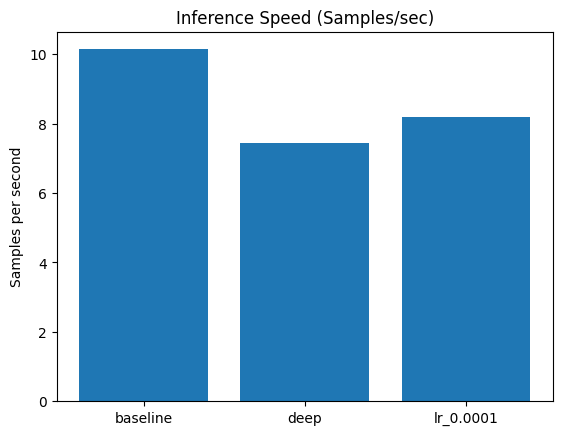

In [83]:
plt.bar(df["model"], df["inference_speed"])
plt.title("Inference Speed (Samples/sec)")
plt.ylabel("Samples per second")
plt.show()

# Training Time

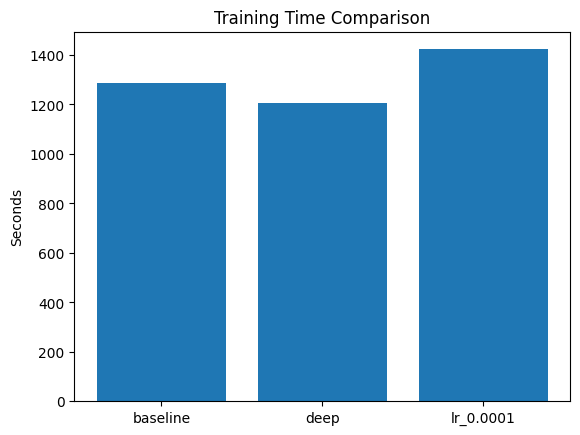

In [84]:
models = [r["model"] for r in results]
times = [r["total_time"] for r in results]

plt.bar(models, times)
plt.title("Training Time Comparison")
plt.ylabel("Seconds")
plt.show()

# Learninig curves (CNN VS FFNN) 

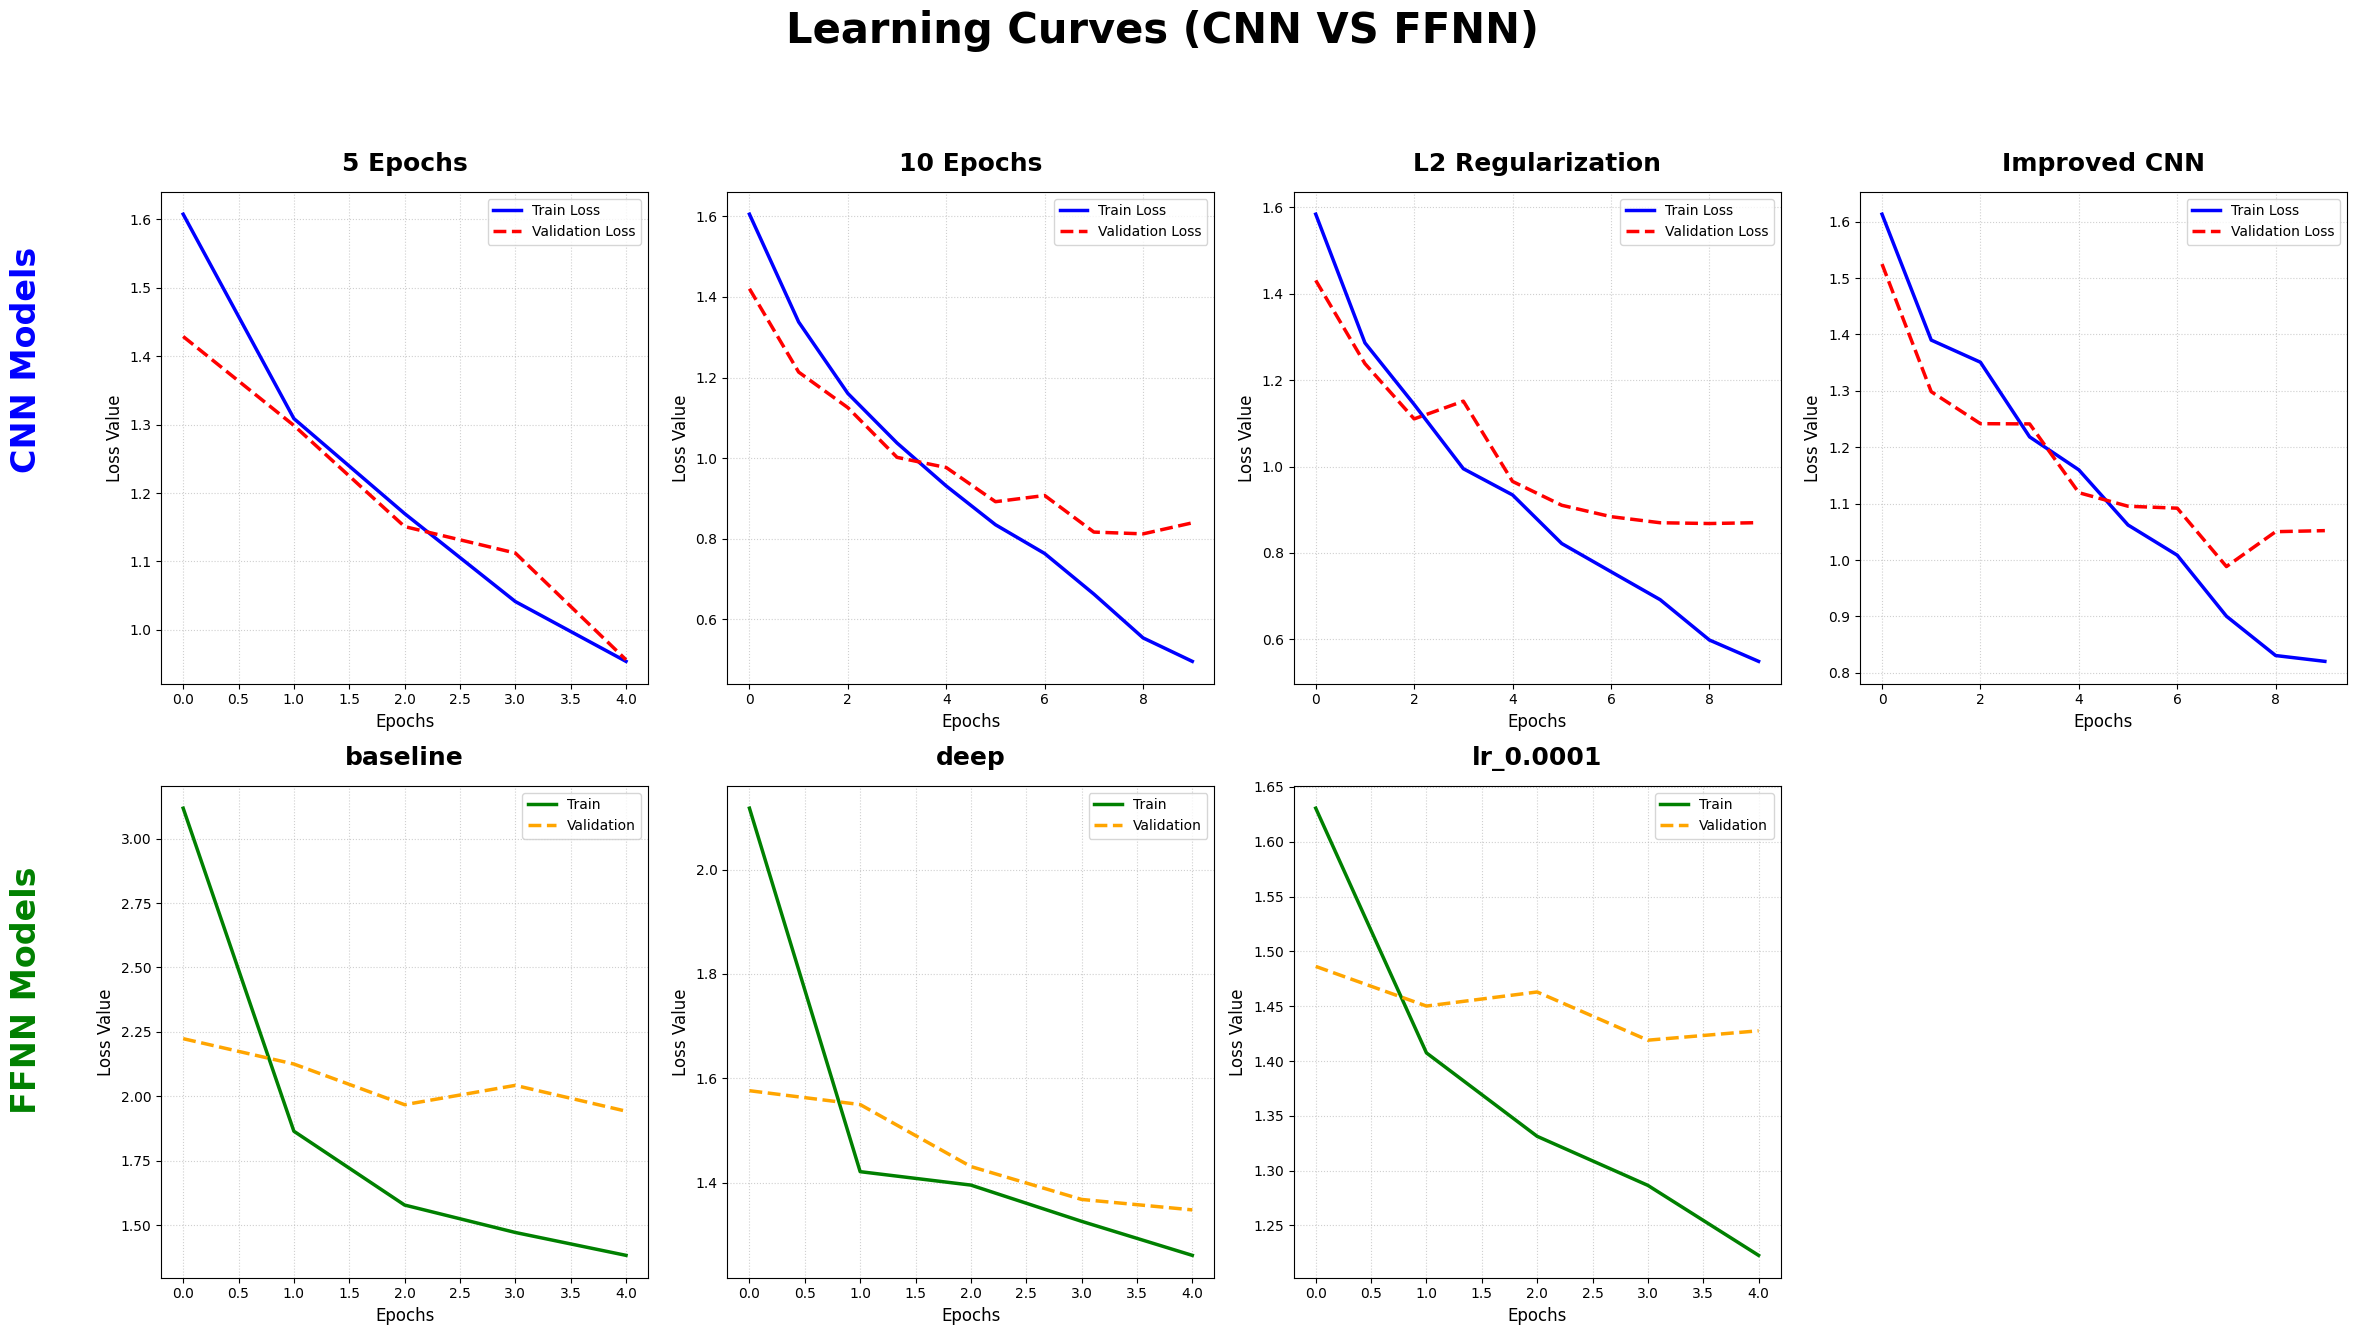

In [94]:
plt.figure(figsize=(24, 14))
plt.suptitle('Learning Curves (CNN VS FFNN)', fontsize=30, fontweight='bold', y=0.98)

histories_cnn = [cnn_history, cnn_history_ep, cnn_history_l2, cnn_history_im]
titles_cnn = ['5 Epochs', '10 Epochs', 'L2 Regularization', 'Improved CNN']

plt.figtext(0.02, 0.73, 'CNN Models', fontsize=24, fontweight='bold', rotation='vertical', va='center', color='blue')
for i, (history, title) in enumerate(zip(histories_cnn, titles_cnn)):
    plt.subplot(2, 4, i + 1)
    plt.plot(history['train_loss'], label='Train Loss', color='blue', linewidth=2.5)
    plt.plot(history['val_loss'], label='Validation Loss', color='red', linestyle='--', linewidth=2.5)
    
    plt.title(title, fontsize=18, fontweight='bold', pad=15)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss Value', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.6)

plt.figtext(0.02, 0.28, 'FFNN Models', fontsize=24, fontweight='bold', rotation='vertical', va='center', color='green')
for i, r in enumerate(results[:3]):
 
    plt.subplot(2, 4, i + 5)
 
    plt.plot(r["train_losses"], label='Train', color='green', linewidth=2.5)
    plt.plot(r["val_losses"], label='Validation', color='orange', linestyle='--', linewidth=2.5)
    
    plt.title(r["model"], fontsize=18, fontweight='bold', pad=15)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss Value', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0.05, 0.03, 1, 0.93])
plt.show()

# CNN vs FFNN best models

| Model | Best version | Accuracy | Inference speed|
|---|---|---|---|
| `CNN` | CNN+L2(10 epochs) | 71.09% | 7.15 samples/sec |
| `FFNN` | Deep | 52.27% | 7.43 samples/sec |

-  Performance: The CNN significantly outperforms the FFNN by 19%. This proves that CNN layers are essential for capturing spatial patterns in image data.
- ​Efficiency: The FFNN is slightly faster due to its simpler architecture, but the difference is marginal (0.28 samples/sec) and does not compensate for the lower accuracy.
- ​Best Strategy: Adding L2 Regularization to the CNN was the most effective optimization, providing the best balance between training depth and generalization.

- ### ​Final Verdict: The CNN + L2 is the superior model for this task.